# Payroll Anomaly Detection for Site Labour
**Author:** Atul Iwale · **Project 4** of the AEC Fieldwork portfolio (machine-learning upgrade)

**Business question:** out of 1,000+ monthly wage lines for contract labour, which few should the payroll auditor check before money leaves the bank?

The first version of this project checked four fixed rules on staff timesheets. Real leakage in construction payroll is mostly in **site labour supplied by labour contractors**. The typical issues are ghost workers, proxy attendance, padded overtime, unauthorised rate increases and wages paid after a worker has left. Nobody labels these in advance, so this is an **unsupervised** problem: the detectors learn what normal looks like and rank what doesn't fit.

The internal-audit outcomes in the workbook are used **only to measure** the detectors, never to train them.

**Contents**
1. Load and audit the data
2. Why rule checks alone don't work
3. Features: compare each line with its peers and its own history
4. Split by time
5. Detectors: rules, robust z-score, Isolation Forest, Local Outlier Factor, One-Class SVM, Autoencoder, ensemble
6. Results at a realistic audit budget
7. What each detector catches and misses
8. Reason codes: why a line was flagged
9. Contractors and approvers
10. This month's audit list (August 2026)
11. Export for the web app

In [1]:
import warnings, json, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score, roc_auc_score
from scipy.stats import rankdata
import tensorflow as tf
tf.keras.utils.set_random_seed(4); tf.config.experimental.enable_op_determinism()
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
DATA = '../data/04_Site_Labour_Payroll_v2.xlsx'

## 1. Load and audit the data

In [2]:
import numpy as np, pandas as pd

def load(path):
    x = pd.read_excel(path, sheet_name=None)
    W, P = x['dim_worker'].copy(), x['fact_payroll_month'].copy()
    P['pay_month'] = pd.to_datetime(P.pay_month); W['join_month'] = pd.to_datetime(W.join_month); W['exit_month'] = pd.to_datetime(W.exit_month)
    return x, W, P

def features(W, P):
    d = P.merge(W[['worker_id', 'trade', 'skill_level', 'join_month', 'exit_month', 'aadhaar_verified', 'pf_uan_linked', 'daily_wage']], on='worker_id', how='left')
    d = d.sort_values(['worker_id', 'pay_month']).reset_index(drop=True)
    paid_days = (d.days_present + d.sundays_worked).clip(lower=1)
    # --- identity / KYC ---
    share = W.groupby('bank_account').worker_id.nunique()
    d['bank_shared_by'] = d.bank_account.map(share).fillna(1) - 1                      # other workers paid into the same account
    d['kyc_missing'] = (d.aadhaar_verified == 'No').astype(int) + (d.pf_uan_linked == 'No').astype(int)
    d['cash_payment'] = (d.payment_mode == 'Cash').astype(int)
    d['tenure_months'] = ((d.pay_month.dt.year - d.join_month.dt.year) * 12 + d.pay_month.dt.month - d.join_month.dt.month).clip(upper=3)   # capped: 'new vs settled', stable over time
    d['paid_after_exit'] = (d.exit_month.notna() & (d.pay_month > d.exit_month)).astype(int)
    # --- attendance, compared with the same site in the same month ---
    d['attendance_ratio'] = d.days_present / d.working_days
    d['manual_share'] = d.manual_days / paid_days
    g = d.groupby(['site', 'pay_month'])
    d['manual_vs_site'] = d.manual_share - g.manual_share.transform('median')
    d['attendance_vs_site'] = d.attendance_ratio - g.attendance_ratio.transform('median')
    d['sundays_vs_site'] = d.sundays_worked - g.sundays_worked.transform('median')
    # --- worker's own history (median of their other months) ---
    wg = d.groupby('worker_id')
    own = lambda c: wg[c].transform(lambda s: s.expanding().median().shift(1))       # past months only
    d['attendance_vs_own'] = d.attendance_ratio - own('attendance_ratio')
    # --- overtime, compared with the same trade on the same site that month ---
    d['ot_per_day'] = d.overtime_hours / paid_days
    tg = d.groupby(['site', 'trade', 'pay_month'])
    med = tg.overtime_hours.transform('median'); mad = tg.overtime_hours.transform(lambda s: (s - s.median()).abs().median())
    d['ot_vs_crew'] = (d.overtime_hours - med) / (mad + 4)
    # --- pay rate ---
    band = d.groupby(['trade', 'pay_month']).daily_rate.transform('median')
    d['rate_vs_trade'] = d.daily_rate / band - 1
    prev = wg.daily_rate.shift(1)
    d['rate_jump'] = np.where(d.pay_month.dt.month == 4, d.daily_rate / prev / 1.08 - 1, d.daily_rate / prev - 1)   # April revision is expected
    d['rate_jump'] = d.rate_jump.fillna(0).round(2)                                   # whole-percent steps; ignores rupee rounding
    d['rate_vs_joining'] = (d.daily_rate / (d.daily_wage * np.where(d.pay_month >= '2026-04-01', 1.08, 1)) - 1).round(2)
    d['gross_per_day'] = d.gross_pay / paid_days
    return d

FEATS = ['bank_shared_by', 'kyc_missing', 'cash_payment', 'tenure_months', 'paid_after_exit', 'attendance_ratio', 'manual_share', 'manual_vs_site', 'attendance_vs_site',
         'sundays_vs_site', 'attendance_vs_own', 'ot_per_day', 'ot_vs_crew', 'rate_vs_trade', 'rate_jump', 'rate_vs_joining', 'gross_per_day']
LABELS = {'bank_shared_by': 'Bank account shared with other workers', 'kyc_missing': 'KYC / PF link missing', 'cash_payment': 'Paid in cash', 'tenure_months': 'Months on site (capped at 3)',
          'paid_after_exit': 'Paid after exit month', 'attendance_ratio': 'Attendance vs working days', 'manual_share': 'Manual (non-biometric) days', 'manual_vs_site': 'Manual days vs site that month',
          'attendance_vs_site': 'Attendance vs site that month', 'sundays_vs_site': 'Sundays worked vs site', 'attendance_vs_own': "Attendance vs worker's own past",
          'ot_per_day': 'Overtime per paid day', 'ot_vs_crew': 'Overtime vs same trade on site', 'rate_vs_trade': 'Daily rate vs trade median', 'rate_jump': 'Rate change vs last month',
          'rate_vs_joining': 'Rate vs agreed joining wage', 'gross_per_day': 'Gross pay per paid day'}

x, W, P = load(DATA)
for k, v in x.items(): print(f'{k:24s} {v.shape[0]:>7,} rows x {v.shape[1]} cols')
staff = pd.read_excel('../data/04_Construction_Payroll.xlsx', sheet_name='dim_employee')
cal = x['site_calendar'].assign(month=lambda z: pd.to_datetime(z.month))
recalc = (P.daily_rate * (P.days_present + P.sundays_worked) + P.overtime_hours * P.daily_rate / 4 + .1 * P.daily_rate * P.sundays_worked).round()
checks = {
  'every payroll line joins to a worker': P.worker_id.isin(W.worker_id).all(),
  'every approver is a staff member in dim_employee': P.approver_id.isin(staff.employee_id).all(),
  'sites are the 12 sites of dim_employee': set(W.site) == set(staff.site),
  'one line per worker per month': not P.duplicated(['worker_id', 'pay_month']).any(),
  'gross pay recomputes from rate, days and overtime (within Rs 2)': (P.gross_pay - recalc).abs().max() <= 2,
  'net = gross - PF - ESI': (P.net_pay == P.gross_pay - P.pf_deduction - P.esi_deduction).all(),
}
for k, v in checks.items(): print('OK ' if v else 'FAIL', k)
print(f"\n{W.worker_id.nunique():,} workers, {W.labour_contractor_id.nunique()} active labour contractors, {P.pay_month.dt.to_period('M').nunique()} months, gross wages Rs {P.gross_pay.sum() / 1e7:.1f} crore")

dim_worker                 1,317 rows x 13 cols
dim_labour_contractor         18 rows x 2 cols
fact_payroll_month        12,397 rows x 19 cols
site_calendar                144 rows x 4 cols
audit_outcome             12,397 rows x 3 cols
data_dictionary_v2            18 rows x 4 cols
OK  every payroll line joins to a worker
OK  every approver is a staff member in dim_employee
OK  sites are the 12 sites of dim_employee
OK  one line per worker per month
OK  gross pay recomputes from rate, days and overtime (within Rs 2)
OK  net = gross - PF - ESI

1,317 workers, 15 active labour contractors, 12 months, gross wages Rs 28.4 crore


Every line recomputes exactly: the arithmetic is right. That is the point. The issues here are not calculation errors that a formula check can catch. The wages are calculated correctly on attendance, overtime or rates that should not have been there.

## 2. Why rule checks alone don't work
A typical audit checklist has seven rules. Each is sensible on its own. Together they produce a flood of alerts, because common gaps (such as a missing PF link) and legitimate site events look like fraud:
- **Concrete-pour pushes:** whole crews work Sundays and heavy overtime.
- **Biometric device faults:** every worker on site is marked manually that month.

In [3]:
au = x['audit_outcome'].set_index('payroll_id')
d = features(W, P)
d['y'] = (d.payroll_id.map(au.audit_outcome) == 'Confirmed issue').astype(int); d['issue_type'] = d.payroll_id.map(au.issue_type)
d = d.merge(cal.rename(columns={'month': 'pay_month'}), on=['site', 'pay_month'], how='left')
RULES = {'More than 4 Sundays paid': d.sundays_worked > 4, 'Manual attendance over 50%': d.manual_share > .5, 'Overtime over 50 h/month': d.overtime_hours > 50,
         'Rate 25% above trade median': d.rate_vs_trade > .25, 'Bank account shared': d.bank_shared_by > 0, 'Paid after exit': d.paid_after_exit == 1, 'KYC or PF link missing': d.kyc_missing >= 1}
rt = pd.DataFrame({k: {'lines flagged': int(v.sum()), 'confirmed issues': int((v & (d.y == 1)).sum()), 'precision': (d.y[v].mean() if v.any() else np.nan),
                       'flags in push or device-fault months': int((v & ((d.concrete_pour_push == 'Yes') | (d.biometric_device_fault == 'Yes'))).sum())} for k, v in RULES.items()}).T
anyr = np.logical_or.reduce(list(RULES.values()))
print(f'Any rule: {anyr.sum():,} lines flagged ({anyr.mean():.1%} of all), of which {d.y[anyr].mean():.1%} are confirmed issues. Recall {d.y[anyr].sum() / d.y.sum():.1%}.')
rt.round(3)

Any rule: 3,009 lines flagged (24.3% of all), of which 13.8% are confirmed issues. Recall 75.0%.


,lines flagged,confirmed issues,precision,flags in push or device-fault months
More than 4 Sundays paid,19.0,4.0,0.211,18.0
Manual attendance over 50%,779.0,147.0,0.189,669.0
Overtime over 50 h/month,204.0,89.0,0.436,123.0
Rate 25% above trade median,63.0,63.0,1.000,3.0
Bank account shared,530.0,173.0,0.326,88.0
Paid after exit,12.0,12.0,1.000,0.0
KYC or PF link missing,1828.0,194.0,0.106,315.0


An auditor cannot check one line in four every month. Rules also miss the subtler cases: proxy attendance that stays under the thresholds, and rate increases that look normal for the trade but not for that worker.

## 3. Features: compare each line with its peers and its own history
The key design choice: a number is only unusual *in context*. Each feature compares the line with:
- **the same site that month** (manual days, attendance, Sundays),
- **the same trade on the same site that month** (overtime),
- **the same trade across sites** (daily rate),
- **the worker's own past** (attendance, rate jumps outside the April revision),
- **identity signals** (shared bank accounts, missing KYC, cash payment, pay after exit).

So a concrete pour that doubles overtime for the whole crew is normal, while one bar bender doing it alone is not.

In [4]:
LABELS

{'bank_shared_by': 'Bank account shared with other workers',
 'kyc_missing': 'KYC / PF link missing',
 'cash_payment': 'Paid in cash',
 'tenure_months': 'Months on site (capped at 3)',
 'paid_after_exit': 'Paid after exit month',
 'attendance_ratio': 'Attendance vs working days',
 'manual_share': 'Manual (non-biometric) days',
 'manual_vs_site': 'Manual days vs site that month',
 'attendance_vs_site': 'Attendance vs site that month',
 'sundays_vs_site': 'Sundays worked vs site',
 'attendance_vs_own': "Attendance vs worker's own past",
 'ot_per_day': 'Overtime per paid day',
 'ot_vs_crew': 'Overtime vs same trade on site',
 'rate_vs_trade': 'Daily rate vs trade median',
 'rate_jump': 'Rate change vs last month',
 'rate_vs_joining': 'Rate vs agreed joining wage',
 'gross_per_day': 'Gross pay per paid day'}

## 4. Split by time
The detectors learn 'normal' from **Sep 2025 to Feb 2026** and are scored on **Mar to Aug 2026**, as they would be used month by month. Settings such as the number of neighbours are chosen using the audit results of the *earlier* period only.

In [5]:
fit = (d.pay_month < '2026-03-01').values; ev = ~fit
imp = SimpleImputer(strategy='median').fit(d.loc[fit, FEATS])
sc = RobustScaler(quantile_range=(5, 95)).fit(imp.transform(d.loc[fit, FEATS]))
CLIP = 10
Z = np.clip(sc.transform(imp.transform(d[FEATS])), -CLIP, CLIP)
print(f'fit period: {fit.sum():,} lines ({d.y[fit].mean():.1%} later confirmed as issues) | evaluation period: {ev.sum():,} lines ({d.y[ev].mean():.1%})')

fit period: 6,025 lines (3.2% later confirmed as issues) | evaluation period: 6,372 lines (5.7%)


## 5. Detectors

In [6]:
SC = {}
SC['Rules (count of rules hit)'] = np.sum([v.values.astype(int) for v in RULES.values()], axis=0) + 0.0
SC['Robust z-score (sum of deviations)'] = np.abs(Z).sum(1)
def pr(s, m): return average_precision_score(d.y[m], s[m])
# Isolation Forest: isolates points that need few random splits
best = None
for ms in (128, 256, 512):
    for mf in (.6, 1.0):
        m = IsolationForest(n_estimators=200, max_samples=ms, max_features=mf, random_state=4).fit(Z[fit]); s = -m.score_samples(Z)
        if best is None or pr(s, fit) > best[1]: best = (m, pr(s, fit), ms, mf)
ifo = best[0]; SC['Isolation Forest'] = -ifo.score_samples(Z); print('Isolation Forest: max_samples', best[2], 'max_features', best[3])
# Local Outlier Factor: density compared with neighbours
best = None
for k in (20, 50, 100, 200, 400):
    m = LocalOutlierFactor(n_neighbors=k, novelty=True).fit(Z[fit]); s = -m.score_samples(Z)
    if best is None or pr(s, fit) > best[1]: best = (m, pr(s, fit), k)
SC['Local Outlier Factor'] = -best[0].score_samples(Z); LOF_K = best[2]; print('LOF: n_neighbors', LOF_K)
# One-Class SVM: a boundary around normal data
best = None
for nu in (.02, .05, .1):
    for g in ('scale', .02):
        m = OneClassSVM(nu=nu, gamma=g).fit(Z[fit]); s = -m.score_samples(Z)
        if best is None or pr(s, fit) > best[1]: best = (m, pr(s, fit), nu, g)
SC['One-Class SVM'] = -best[0].score_samples(Z); print('One-Class SVM: nu', best[2], 'gamma', best[3])

Isolation Forest: max_samples 512 max_features 1.0


LOF: n_neighbors 200


One-Class SVM: nu 0.1 gamma scale


**Autoencoder.** A neural network learns to compress each line into 4 numbers and rebuild it. It is trained on the fit period, so it learns to rebuild normal lines well. Lines it cannot rebuild are unusual. The reconstruction error per feature also explains *what* was unusual.

In [7]:
nF = len(FEATS)
inp = tf.keras.Input((nF,)); h = tf.keras.layers.Dense(16, activation='relu')(inp); h = tf.keras.layers.Dense(4, activation='relu')(h)
h = tf.keras.layers.Dense(16, activation='relu')(h); out = tf.keras.layers.Dense(nF)(h)
ae = tf.keras.Model(inp, out); ae.compile(tf.keras.optimizers.Adam(3e-3), 'mse')
Zf = Z[fit].astype('float32')
hist_ = ae.fit(Zf, Zf, epochs=120, batch_size=128, validation_split=.15, verbose=0, callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
REC = ae.predict(Z.astype('float32'), verbose=0)
SC['Autoencoder (neural network)'] = ((REC - Z) ** 2).mean(1)
print('autoencoder trained for', len(hist_.history['loss']), 'epochs')
# Ensemble: average rank of Isolation Forest, Autoencoder and robust z-score
ENS = ['Isolation Forest', 'Autoencoder (neural network)', 'Robust z-score (sum of deviations)']
SC['Ensemble (IF + Autoencoder + z-score)'] = np.mean([rankdata(SC[k]) / len(Z) for k in ENS], axis=0)

autoencoder trained for 24 epochs


## 6. Results at a realistic audit budget
An auditor can review a fixed number of lines each month. So the key measures are **precision** (share of reviewed lines that are real issues) and **recall** (share of all issues found), when reviewing the top 2% or 5% of lines each month.

In [8]:
E = d[ev].copy()
def at_budget(s, pct):
    E_ = E.assign(s=s[ev]); E_['rank'] = E_.groupby('pay_month').s.rank(ascending=False, method='first'); E_['n'] = E_.groupby('pay_month').s.transform('size')
    top = E_['rank'] <= np.ceil(E_.n * pct); return top.values
rows = {}
for n, s in SC.items():
    r = {'PR-AUC': average_precision_score(E.y, s[ev]), 'ROC-AUC': roc_auc_score(E.y, s[ev])}
    for pct in (.02, .05):
        t = at_budget(s, pct); r[f'precision @{pct:.0%}'] = E.y[t].mean(); r[f'recall @{pct:.0%}'] = E.y[t].sum() / E.y.sum()
    rows[n] = r
res = pd.DataFrame(rows).T.sort_values('PR-AUC', ascending=False)
print(f'Evaluation months: {ev.sum():,} lines, {E.y.sum()} confirmed issues ({E.y.mean():.1%}). A random pick would have precision {E.y.mean():.1%}.')
res.round(3)

Evaluation months: 6,372 lines, 364 confirmed issues (5.7%). A random pick would have precision 5.7%.


,PR-AUC,ROC-AUC,precision @2%,recall @2%,precision @5%,recall @5%
Isolation Forest,0.837,0.964,1.000,0.357,0.829,0.734
Ensemble (IF + Autoencoder + z-score),0.783,0.957,1.000,0.357,0.748,0.662
Robust z-score (sum of deviations),0.780,0.961,1.000,0.357,0.742,0.657
One-Class SVM,0.772,0.962,0.954,0.341,0.755,0.668
Local Outlier Factor,0.684,0.940,0.954,0.341,0.683,0.604
Autoencoder (neural network),0.681,0.912,0.923,0.330,0.683,0.604
Rules (count of rules hit),0.373,0.809,0.600,0.214,0.460,0.407


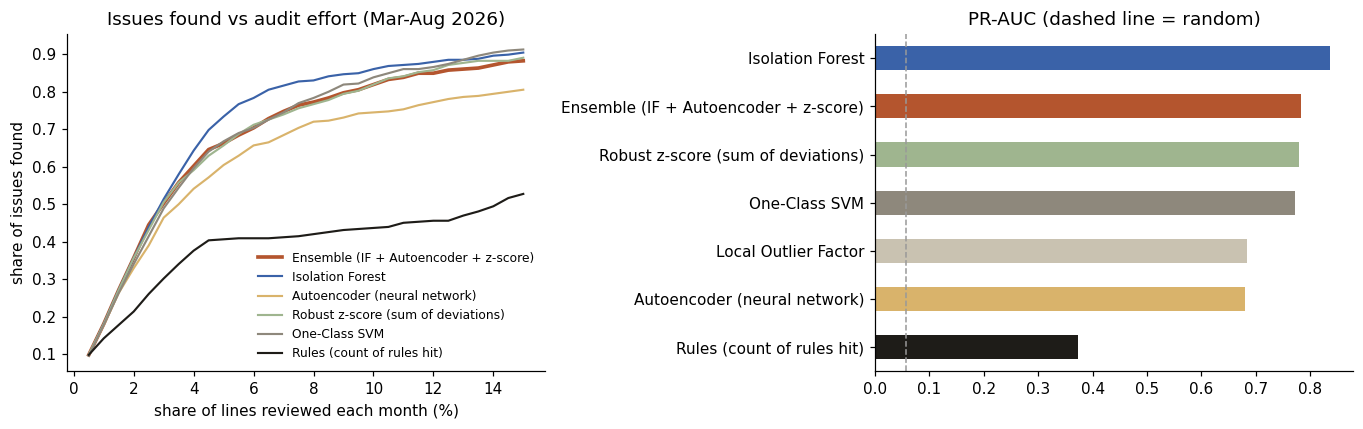

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
budgets = np.arange(.005, .151, .005)
cols = {'Ensemble (IF + Autoencoder + z-score)': '#b4552e', 'Isolation Forest': '#3a62a8', 'Autoencoder (neural network)': '#d9b36b', 'Robust z-score (sum of deviations)': '#9fb58f',
        'One-Class SVM': '#8e887c', 'Rules (count of rules hit)': '#1e1c18'}
for n, c in cols.items():
    ax[0].plot(budgets * 100, [E.y[at_budget(SC[n], b)].sum() / E.y.sum() for b in budgets], color=c, lw=2.4 if n.startswith('Ens') else 1.4, label=n)
ax[0].set_xlabel('share of lines reviewed each month (%)'); ax[0].set_ylabel('share of issues found'); ax[0].legend(frameon=False, fontsize=8); ax[0].set_title('Issues found vs audit effort (Mar-Aug 2026)')
res['PR-AUC'].sort_values().plot.barh(ax=ax[1], color=[cols.get(i, '#c9c2b1') for i in res['PR-AUC'].sort_values().index]); ax[1].axvline(E.y.mean(), color='#999', ls='--', lw=1)
ax[1].set_title('PR-AUC (dashed line = random)'); plt.tight_layout(); plt.show()

## 7. What each detector catches and misses
Recall by issue type when the auditor reviews the top 5% of lines each month.

In [10]:
bt = pd.DataFrame({n: {t: (E.issue_type[at_budget(s, .05)] == t).sum() / (E.issue_type == t).sum() for t in E.issue_type.dropna().unique()} for n, s in SC.items()}).T
bt.insert(0, 'all issues', res['recall @5%']); bt.loc['(issue lines in evaluation period)'] = [E.y.sum()] + [int((E.issue_type == t).sum()) for t in bt.columns[1:]]
bt.round(2)

,all issues,Overtime padding,Proxy attendance,Paid after exit,Unauthorised wage increase,Ghost worker
Rules (count of rules hit),0.41,0.31,0.08,1.00,0.32,0.54
Robust z-score (sum of deviations),0.66,0.95,0.21,1.00,0.23,0.88
Isolation Forest,0.73,0.74,0.08,1.00,0.87,0.85
Local Outlier Factor,0.60,0.83,0.12,1.00,0.37,0.77
One-Class SVM,0.67,0.98,0.15,1.00,0.37,0.85
Autoencoder (neural network),0.60,0.26,0.13,0.86,0.55,0.83
Ensemble (IF + Autoencoder + z-score),0.66,0.48,0.13,1.00,0.56,0.88
(issue lines in evaluation period),364.00,42.00,52.00,7.00,78.00,185.00


- **Isolation Forest** is the strongest all-rounder. It catches ghost workers, unauthorised rate increases and pay after exit, because these differ from peers on several features at once.
- **The autoencoder** is good at rate increases and ghosts but weak on padded overtime. It learns to rebuild overtime from the other features, so a single extreme value is partly 'explained away'.
- **The robust z-score and One-Class SVM** are best on padded overtime, where one feature is extreme, but weak on rate increases.
- **Proxy attendance is the hardest.** A few extra manual days look like an ordinary absence pattern. It needs worker-level history over several months, or a check at the gate.
- **Local Outlier Factor struggles with clustered fraud.** Ghost workers created by the same contractor look alike, so they form their own dense cluster and seem 'normal' to a density method. This is known as *masking*. Isolation-based methods are less affected.
- **Rules** are precise for hard facts (pay after exit), but miss anything that stays under a threshold.

## 8. Reason codes: why a line was flagged
A flag an auditor can't explain won't be acted on. For each line, the features that are rarest compared with the fit-period distribution (in the top or bottom 2%) become its reason codes, for example *Paid after exit month (high, rarest 0.1%)*.

In [11]:
XI = imp.transform(d[FEATS])                                   # raw values, gaps filled with the fit-period median
QG = np.quantile(XI[fit], np.linspace(0, 1, 1001), axis=0)      # fit-period distribution of every feature
def rarity(v, j):
    hi = 1 - np.searchsorted(QG[:, j], v, 'left') / 1001; lo = np.searchsorted(QG[:, j], v, 'right') / 1001
    return (hi, 'high') if hi <= lo else (lo, 'low')
def reasons(i, k=3):
    r = sorted(((rarity(XI[i, j], j), j) for j in range(len(FEATS))), key=lambda z: z[0][0])
    return [f"{LABELS[FEATS[j]]} ({side}, rarest {max(p, .001):.1%})" for (p, side), j in r[:k] if p <= .02]
ens = SC['Isolation Forest']   # the best single detector on the evaluation months drives the worklist
ex = np.where(ev)[0][np.argsort(-ens[ev])[:8]]
pd.DataFrame({'payroll_id': d.payroll_id.values[ex], 'worker': d.worker_id.values[ex], 'site': d.site.values[ex], 'month': d.pay_month.dt.strftime('%b %Y').values[ex],
              'reasons': ['; '.join(reasons(i)) for i in ex], 'audit result': d.issue_type.fillna('No issue').values[ex]})

,payroll_id,worker,site,month,reasons,audit result
0,PAY010616,WRK01316,Chennai Highway Package 1,Jul 2026,"Manual (non-biometric) days (high, rarest 0.4%...",Ghost worker
1,PAY011524,WRK00184,Bengaluru Industrial Plant 1,Aug 2026,"Paid after exit month (high, rarest 0.1%); Att...",Paid after exit
2,PAY007369,WRK01316,Chennai Highway Package 1,Apr 2026,"Manual (non-biometric) days (high, rarest 0.3%...",Ghost worker
3,PAY006204,WRK01306,Bengaluru Industrial Plant 1,Mar 2026,"Manual (non-biometric) days (high, rarest 0.4%...",Ghost worker
4,PAY008456,WRK01316,Chennai Highway Package 1,May 2026,"Manual (non-biometric) days (high, rarest 0.4%...",Ghost worker
5,PAY008911,WRK01291,Kochi IT Park 2,May 2026,"Bank account shared with other workers (high, ...",Ghost worker
6,PAY011650,WRK01316,Chennai Highway Package 1,Aug 2026,"Manual (non-biometric) days (high, rarest 0.5%...",Ghost worker
7,PAY009538,WRK01316,Chennai Highway Package 1,Jun 2026,"Manual (non-biometric) days (high, rarest 0.4%...",Ghost worker


## 9. Contractors and approvers
Fraud in labour payroll is rarely one line. Rolling the scores up shows *where* to look.

In [12]:
E['flag'] = at_budget(ens, .05)
lcs = x['dim_labour_contractor'].set_index('labour_contractor_id').contractor_name
con = E.groupby('labour_contractor_id').agg(lines=('y', 'size'), flagged_share=('flag', 'mean'), confirmed_share=('y', 'mean'), workers=('worker_id', 'nunique')).sort_values('flagged_share', ascending=False)
con.insert(0, 'contractor', con.index.map(lcs))
fleet_rate = E.flag.mean(); print(f'Fleet flag rate {fleet_rate:.1%}. Contractors flagged at 2x that rate or more:', con[con.flagged_share >= 2 * fleet_rate].contractor.tolist())
con.head(8).round(3)

Fleet flag rate 5.1%. Contractors flagged at 2x that rate or more: ['Royal Manpower Solutions', 'Deccan Manpower', 'Maa Durga Contractors']


,contractor,lines,flagged_share,confirmed_share,workers
labour_contractor_id,,,,,
LC11,Royal Manpower Solutions,342,0.202,0.205,61
LC15,Deccan Manpower,421,0.138,0.157,78
LC04,Maa Durga Contractors,839,0.114,0.133,156
LC09,Sri Venkateswara Manpower,445,0.056,0.054,83
LC05,Jai Hind Manpower Services,97,0.041,0.021,17
LC06,Krishna Labour Contractors,280,0.032,0.021,52
LC17,Apex Site Services,506,0.030,0.036,96
LC01,Shree Ganesh Labour Supply,478,0.027,0.038,90


In [13]:
jumps = E[(E.rate_jump > .15)]
appr = E.assign(jump=E.rate_jump > .15).groupby('approver_id').agg(lines=('y', 'size'), rate_jumps=('jump', 'sum'), flagged=('flag', 'sum')).sort_values('rate_jumps', ascending=False)
appr = appr.join(staff.set_index('employee_id')[['name', 'role', 'site']]); appr.head(5)

,lines,rate_jumps,flagged,name,role,site
approver_id,,,,,,
EMP0012,158,6,57,Diya Chopra,Planning Engineer,Kochi IT Park 2
EMP0032,215,3,34,Diya Kapoor,Civil Supervisor,Chennai Highway Package 1
EMP0001,108,0,0,Aarav Sharma,Site Engineer,Mumbai Metro Viaduct 1
EMP0016,121,0,5,Sneha Iyer,Site Engineer,Noida Logistics Hub 1
EMP0002,148,0,1,Vivaan Mehta,Civil Supervisor,Pune IT Park 1


Two approvers account for almost every mid-year rate increase outside the April revision. That is a control finding (segregation of duties for rate changes), not just a list of lines.

## 10. This month's audit list (August 2026)

In [14]:
LAST = d.pay_month.max(); cur = np.where((d.pay_month == LAST).values)[0]
K = int(np.ceil(len(cur) * .05))
top = cur[np.argsort(-ens[cur])[:K]]
wl = pd.DataFrame({'payroll_id': d.payroll_id.values[top], 'worker_id': d.worker_id.values[top], 'trade': d.trade.values[top], 'site': d.site.values[top], 'contractor': d.labour_contractor_id.values[top],
                   'gross_pay': d.gross_pay.values[top], 'score': ens[top].round(3), 'reasons': ['; '.join(reasons(i)) for i in top], 'audit result': d.issue_type.fillna('No issue').values[top]})
print(f'{LAST:%B %Y}: {len(cur):,} lines, top {K} for review, of which {(wl["audit result"] != "No issue").sum()} turned out to be real issues; Rs {wl.gross_pay.sum() / 1e5:.1f} lakh under review')
wl.head(12)

August 2026: 1,012 lines, top 51 for review, of which 48 turned out to be real issues; Rs 15.0 lakh under review


,payroll_id,worker_id,trade,site,contractor,gross_pay,score,reasons,audit result
0,PAY011524,WRK00184,Equipment Operator,Bengaluru Industrial Plant 1,LC08,18354,0.696,"Paid after exit month (high, rarest 0.1%); Att...",Paid after exit
1,PAY011650,WRK01316,Equipment Operator,Chennai Highway Package 1,LC15,42647,0.673,"Manual (non-biometric) days (high, rarest 0.5%...",Ghost worker
2,PAY012148,WRK01287,Welder,Kolkata Water Treatment Plant 1,LC04,30322,0.662,"Manual (non-biometric) days (high, rarest 0.4%...",Ghost worker
3,PAY012072,WRK01291,Carpenter (shuttering),Kochi IT Park 2,LC04,26819,0.650,"Bank account shared with other workers (high, ...",Ghost worker
4,PAY012073,WRK01292,Welder,Kochi IT Park 2,LC04,36475,0.649,"Manual (non-biometric) days (high, rarest 0.5%...",Ghost worker
5,PAY012069,WRK01286,Bar Bender,Kochi IT Park 2,LC04,31302,0.649,"Bank account shared with other workers (high, ...",Ghost worker
6,PAY011647,WRK01311,Mason,Chennai Highway Package 1,LC15,29487,0.643,"Bank account shared with other workers (high, ...",Ghost worker
7,PAY011549,WRK01302,Unskilled labour,Bengaluru Industrial Plant 1,LC11,21683,0.642,"KYC / PF link missing (high, rarest 0.6%); Man...",Ghost worker
8,PAY011551,WRK01306,Semi-skilled helper,Bengaluru Industrial Plant 1,LC11,25985,0.641,"Manual days vs site that month (high, rarest 0...",Ghost worker
9,PAY012035,WRK00822,Equipment Operator,Kochi IT Park 2,LC04,53623,0.640,"Daily rate vs trade median (high, rarest 0.1%)...",Unauthorised wage increase


## 11. Export for the web app
The browser app runs the same Isolation Forest (its trees) and the same autoencoder (its weights) on every line, so a user can see scores computed live and compare methods at any audit budget.

In [15]:
def tree_json(est, feats):
    t = est.tree_
    return {'l': t.children_left.tolist(), 'r': t.children_right.tolist(), 'f': [int(feats[i]) if i >= 0 else -1 for i in t.feature], 'th': [float(v) for v in t.threshold], 'n': t.n_node_samples.tolist()}
iforest = {'max_samples': int(ifo.max_samples_), 'offset': float(ifo.offset_), 'trees': [tree_json(e, f) for e, f in zip(ifo.estimators_, ifo.estimators_features_)]}
aew = [[w.tolist() for w in l.get_weights()] for l in ae.layers if l.get_weights()]
cur_ix = cur
lines = []
for i in np.where(ev)[0]:
    lines.append([d.payroll_id.values[i], d.worker_id.values[i], d.pay_month.values[i].astype('datetime64[M]').astype(str), d.site.values[i], d.labour_contractor_id.values[i], d.trade.values[i],
                  int(d.gross_pay.values[i]), int(d.y.values[i]), d.issue_type.values[i] if isinstance(d.issue_type.values[i], str) else None,
                  [None if pd.isna(v) else float(v) for v in d[FEATS].values[i]],
                  {k[:3]: round(float(SC[k][i]), 6) for k in SC}])
KEYS = {k[:3]: k for k in SC}
export = {'features': FEATS, 'labels': LABELS, 'qgrid': QG.T.round(6).tolist(), 'medians': imp.statistics_.tolist(), 'center': sc.center_.tolist(), 'scale': sc.scale_.tolist(), 'clip': CLIP,
          'iforest': iforest, 'ae': aew, 'keys': KEYS, 'ens': [k[:3] for k in ENS], 'lines': lines, 'cols': ['payroll_id', 'worker_id', 'month', 'site', 'contractor', 'trade', 'gross', 'y', 'issue', 'x', 'scores'],
          'results': res.reset_index().rename(columns={'index': 'method'}).to_dict(orient='records'), 'by_type': bt.drop(index='(issue lines in evaluation period)').reset_index().rename(columns={'index': 'method'}).to_dict(orient='records'),
          'type_counts': bt.loc['(issue lines in evaluation period)'].to_dict(), 'rules': rt.reset_index().rename(columns={'index': 'rule'}).replace({np.nan: None}).to_dict(orient='records'),
          'any_rule': {'flagged': int(anyr.sum()), 'share': float(anyr.mean()), 'precision': float(d.y[anyr].mean()), 'recall': float(d.y[anyr].sum() / d.y.sum())},
          'contractors': con.reset_index().to_dict(orient='records'), 'approvers': appr.head(6).reset_index().rename(columns={'index': 'approver_id'}).to_dict(orient='records'),
          'workers': W.set_index('worker_id')[['worker_name', 'trade', 'skill_level', 'labour_contractor_id', 'site', 'join_month', 'exit_month', 'daily_wage', 'payment_mode', 'aadhaar_verified', 'pf_uan_linked']]
                      .assign(join_month=lambda z: z.join_month.dt.strftime('%Y-%m'), exit_month=lambda z: z.exit_month.dt.strftime('%Y-%m')).replace({np.nan: None}).to_dict(orient='index'),
          'lc_names': lcs.to_dict(), 'lof_k': LOF_K}
export['workers'] = {k: v for k, v in export['workers'].items() if k in set(d.worker_id[ev])}
with open('../model/anomaly_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'), allow_nan=False, default=str)
print('Exported', len(iforest['trees']), 'isolation trees, autoencoder', [len(w[1]) for w in aew], ',', len(lines), 'lines |', f"{os.path.getsize('../model/anomaly_export.json') / 1e6:.2f} MB")

Exported 200 isolation trees, autoencoder [16, 4, 16, 17] , 6372 lines | 3.63 MB


## Summary
- **Data:** 12 months of site-labour payroll: about 1,300 workers from 18 labour contractors on the same 12 sites and approvers as the staff payroll. Every line recomputes correctly, so the issues are in the inputs, not the arithmetic.
- **Rules alone:** the seven-rule checklist flags about one line in four, and 86% of those flags are false alarms (missing PF links, concrete-pour pushes, biometric faults). It still misses subtle cases.
- **Unsupervised ML:** features that compare each line with its site, its crew and the worker's own history let the **Isolation Forest** put 73% of all real issues into the top 5% of lines, with 83% precision, against 41% recall and 46% precision for the rules (section 6). The robust z-score, One-Class SVM, Local Outlier Factor and autoencoder follow. Averaging detectors into an ensemble did *not* beat the Isolation Forest alone, so the worklist uses the Isolation Forest. All detectors were tuned only on earlier months and scored on six later months.
- **Explainable:** every flag carries reason codes. Rolling scores up by contractor and approver turns line flags into control findings.
- **Honest limits:** the data is synthetic. Proxy attendance remains hard to detect from payroll data alone. Audit outcomes exist only for reviewed lines in real life, so precision would be measured on the reviewed sample and the models retrained as audit results come in.